# TS2 - DFT propia

Sofi Agüero - PDS

Funcion que calcula la DFT: XX = mi_funcion_DFT(xx)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

## Generador de senoidales (de TS1)

In [9]:
# vmax = amplitud, dc = offset, ff = frecuencia, ph = fase, nn = cant muestras, fs = frec de muestreo

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(nn) / fs                       # arange me da 0,1,2...nn-1 (los indices n); al dividir por fs paso de "muestra numero n" a "instante en segundos", que es lo que necesito para evaluar el seno
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)    # aca meto directo la formula de la senoidal: dc es el offset que suma o resta a toda la señal, vmax multiplica la amplitud, y adentro del seno 2*pi*ff*tt+ph es la fase instantanea (fase que arranca en ph y avanza segun la frecuencia)
    
    tt = tt.reshape(nn,1)     # tt me queda como vector fila (nn,) por como lo arme con arange, lo paso a columna (nn,1) porque asi lo pide la consigna
    xx = xx.reshape(nn,1)     # mismo motivo para xx, ademas asi tt y xx quedan con la misma forma y se pueden graficar o guardar juntos sin lios
    
    return tt, xx

## DFT propia

X[k] = sumatoria de x[n] * e^(-j*2*pi*k*n/N), para n=0..N-1

hago los dos for tal cual la formula: uno recorre las frecuencias k, el de adentro recorre las muestras n y arma la sumatoria.

In [10]:
def mi_funcion_DFT(xx):
    xx = xx.flatten()      # viene como columna Nx1, la aplano para poder indexar xx[n] como numero
    N = len(xx)
    
    XX = np.zeros(N, dtype=complex)   # complex porque la DFT da fase tambien, no solo modulo
    
    for k in range(N):
        suma = 0
        for n in range(N):
            suma += xx[n] * np.exp(-1j*2*np.pi*k*n/N)
        XX[k] = suma
    
    return XX.reshape(N,1)   # la devuelvo como columna, mismo criterio que xx

### idem pero con matrices

In [11]:

def mi_funcion_DFT_vectorizada(xx):
    xx = xx.flatten()          # mismo motivo que en la version con for: 
    #la necesito como vector para que las cuentas de abajo den bien las dimensiones
    N = len(xx)
    n = np.arange(N)           # vector fila con los indices 0,1,2...N-1 (el "n" de la formula
    k = n.reshape(N,1)         # el mismo rango pero como columna; al multiplicar una columna (N,1) por una fila (N,),
    #entiendo que numpy expande solo y arma una matriz NxN con TODAS las combinaciones de k*n, 
    #sin que yo tenga que hacer el for
    e = np.exp(-1j*2*np.pi*k*n/N)     # aplico la exponencial a toda esa matriz de una: la fila k, columna n, 
    #me queda el fasor e^(-j2pikn/N) de esa combinacion puntual. O sea, esta matriz ya tiene armados TODOS los 
    # terminos de TODAS las sumatorias (una por cada k)
    return (e @ xx).reshape(N,1)      # @ es producto matricial: multiplica la matriz e (NxN) 
#por el vector xx (N,), y en cada fila k SUMA automaticamente los N productos de esa fila. 
# 3so es exactamente lo que hacia mi doble for, pero resuelto de una sola vez

## Pruebo con una senoidal, tiene que aparecer una delta en f0

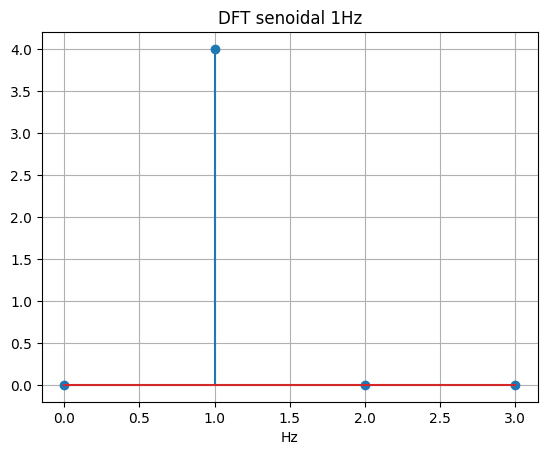

In [12]:
N = 8    # cantidad de muestras que quiero
fs = 8   # elijo fs = N para que la resolucion (fs/N) me de 1Hz por bin
f0 = 1   # frecuencia de la senoidal: la elijo igual a un multiplo de la resolucion (1Hz), asi cae justo en el bin k=1 y no se dispersa

tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=f0, ph=0, nn=N, fs=fs)   # genero la senoidal de prueba, con la frecuencia f0 que quiero verificar
XX = mi_funcion_DFT(xx)                                           # le calculo la DFT con mi propia funcion

ff = np.arange(N) * fs/N          # el eje de k (0,1,2...N-1) no es frecuencia todavia, son solo indices; para pasarlo a Hz uso f_k = k*fs/N, que sale del mismo exponente de la formula de la DFT
modulo = np.abs(XX).flatten()     # XX es complejo (tiene real e imaginaria), me quedo con el modulo porque quiero ver "cuanta energia" hay en cada frecuencia, no la fase; ademas aplano porque plt.stem necesita un vector 1D, no columna

plt.figure()
plt.stem(ff[:N//2], modulo[:N//2])   # con la mitad alcanza, la otra mitad es simetrica (xx real)
plt.title(f'DFT senoidal {f0}Hz')
plt.xlabel('Hz')
plt.grid()

# da un solo palito en 1Hz como esperaba: una senoidal pura tiene una sola
# frecuencia, y el resto de los terminos de la sumatoria se cancelan entre si

## bonus: comparo contra la FFT de numpy

True


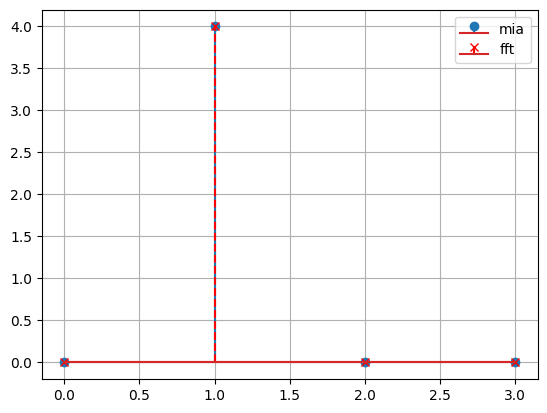

In [13]:
 
XX_fft = np.fft.fft(xx.flatten())        # calculo la misma DFT pero con la funcion de numpy, para comparar
print(np.allclose(XX.flatten(), XX_fft))   # da true si mi funcion esta bien
 
# no comparo con == porque son cuentas hechas de formas distintas, arrastran
# redondeos distintos aunque den lo mismo
 
plt.figure()
plt.stem(ff[:N//2], modulo[:N//2], label='mia')                              # mi resultado
plt.stem(ff[:N//2], np.abs(XX_fft)[:N//2], linefmt='r--', markerfmt='rx', label='fft')   # el de numpy, superpuesto
plt.legend()
plt.grid()
 
# si los dos stem quedan pisados uno arriba del otro, es porque coinciden

## bonu: ruido uniforme con varianza 4

3.868005843057228


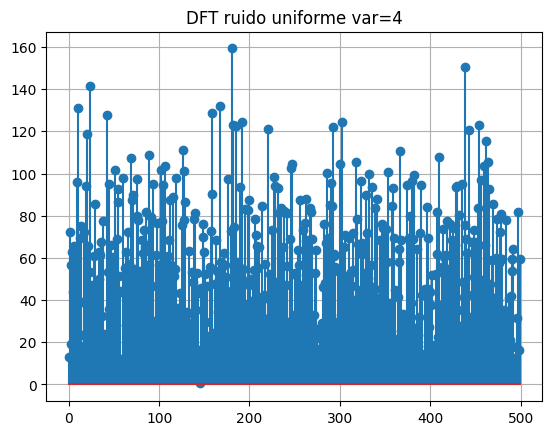

In [14]:
# uniform[a,b] tiene varianza (b-a)^2/12. quiero media 0 y varianza 4,
# entonces planteo [-A,A]: (2A)^2/12=4 -> A=raiz(12)
 
# uso mas muestras aca (N=8 del ejemplo anterior es muy poco para estimar
# bien una varianza y ver el espectro del ruido)
N_ruido = 1000     # uso mas muestras que en la senoidal, con 8 no alcanza para ver bien el espectro del ruido
fs_ruido = 1000
 
A = np.sqrt(12)                                       # sale de la cuenta de arriba: (2A)^2/12=4 -> A=raiz(12)
ruido = (np.random.random_sample(N_ruido) - 0.5) * 2*A   # random_sample da uniforme en [0,1); le resto 0.5 para centrarlo en [-0.5,0.5) y 
#que tenga media 0 (sino el offset positivo me mete un pico falso en frecuencia 0, after eso lo multiplico por 2*A para estirar ese intervalo a
#  [-A,A), que es el ancho que hace que la varianza de la uniforme ((2A)^2/12) me de justo 4 
print(np.var(ruido))   # deberia dar cerca de 4
 
XX_r = mi_funcion_DFT(ruido)                          # le calculo la DFT como a cualquier señal
ff_ruido = np.arange(N_ruido) * fs_ruido/N_ruido      # eje en Hz, mismo criterio que antes
 
plt.figure()
plt.stem(ff_ruido[:N_ruido//2], np.abs(XX_r).flatten()[:N_ruido//2])
plt.title('DFT ruido uniforme var=4')
plt.grid()
 
# aca no hay delta, la energia queda repartida en todas las frecuencias
# porque el ruido no tiene una frecuencia particular, tiene un poco de todas